In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("/content/churn_data.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,ID1,Male,0,Yes,No,1,Yes,No,DSL,No,...,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,21.5,21.5,0
1,ID2,Female,1,No,Yes,2,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Yes,One year,No,Mailed check,22.5,45.0,0
2,ID3,Male,0,Yes,No,3,Yes,No phone service,No,No,...,Yes,No,Yes,No,Two year,Yes,Bank transfer (automatic),23.5,70.5,0
3,ID4,Female,1,No,Yes,4,Yes,No,DSL,Yes,...,No,Yes,No,Yes,Month-to-month,No,Credit card (automatic),24.5,98.0,0
4,ID5,Male,0,Yes,No,5,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,No,One year,Yes,Electronic check,25.5,127.5,0


In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1000 non-null   object 
 1   gender            1000 non-null   object 
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   object 
 4   Dependents        1000 non-null   object 
 5   tenure            1000 non-null   int64  
 6   PhoneService      1000 non-null   object 
 7   MultipleLines     1000 non-null   object 
 8   InternetService   1000 non-null   object 
 9   OnlineSecurity    1000 non-null   object 
 10  OnlineBackup      1000 non-null   object 
 11  DeviceProtection  1000 non-null   object 
 12  TechSupport       1000 non-null   object 
 13  StreamingTV       1000 non-null   object 
 14  StreamingMovies   1000 non-null   object 
 15  Contract          1000 non-null   object 
 16  PaperlessBilling  1000 non-null   object 
 

/tmp/ipykernel_402/331449706.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


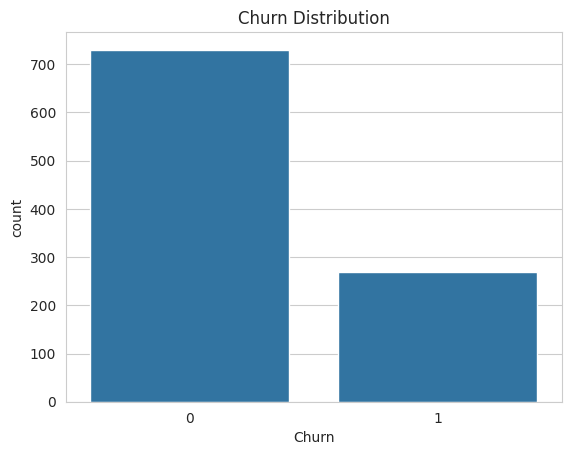

In [5]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

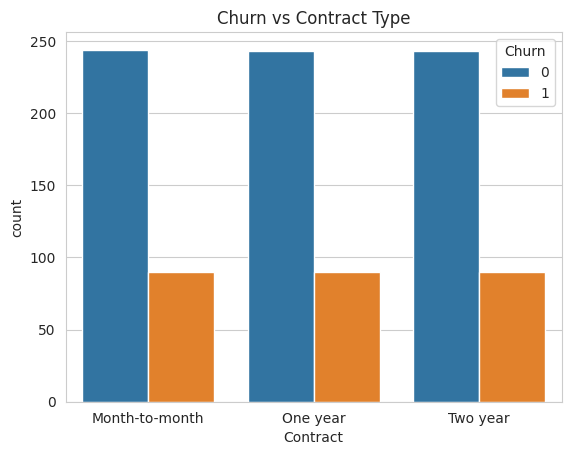

In [6]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn vs Contract Type")
plt.show()

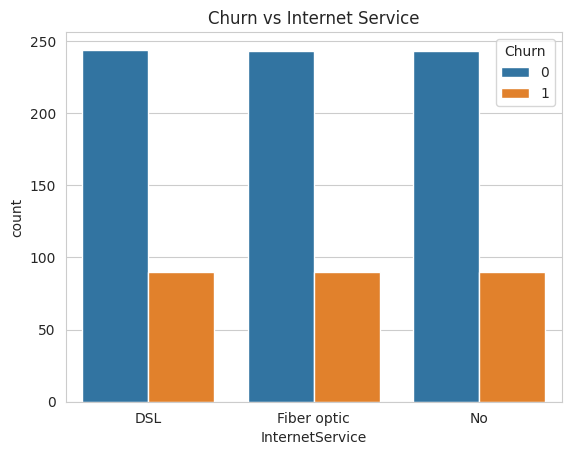

In [7]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn vs Internet Service")
plt.show()

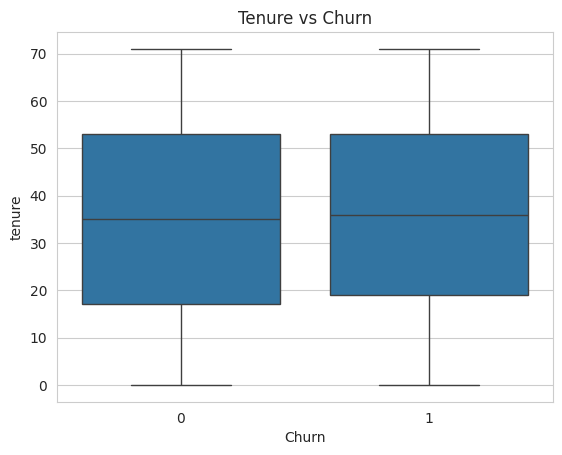

In [8]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

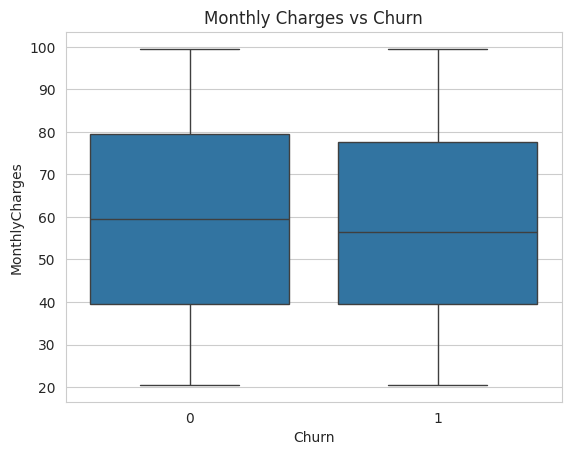

In [9]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

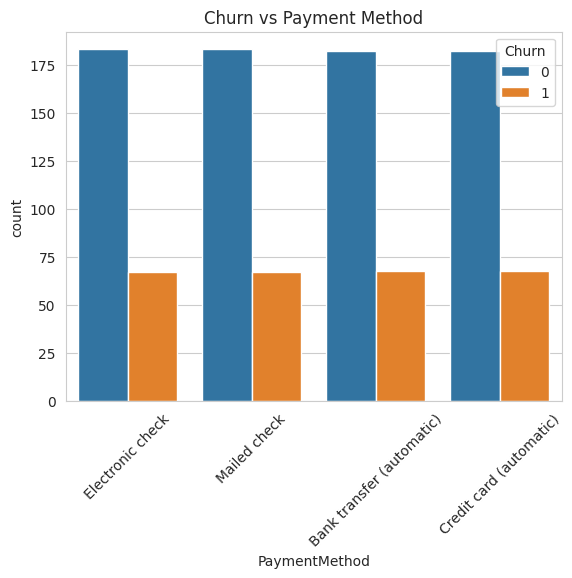

In [10]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=45)
plt.title("Churn vs Payment Method")
plt.show()

In [11]:
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

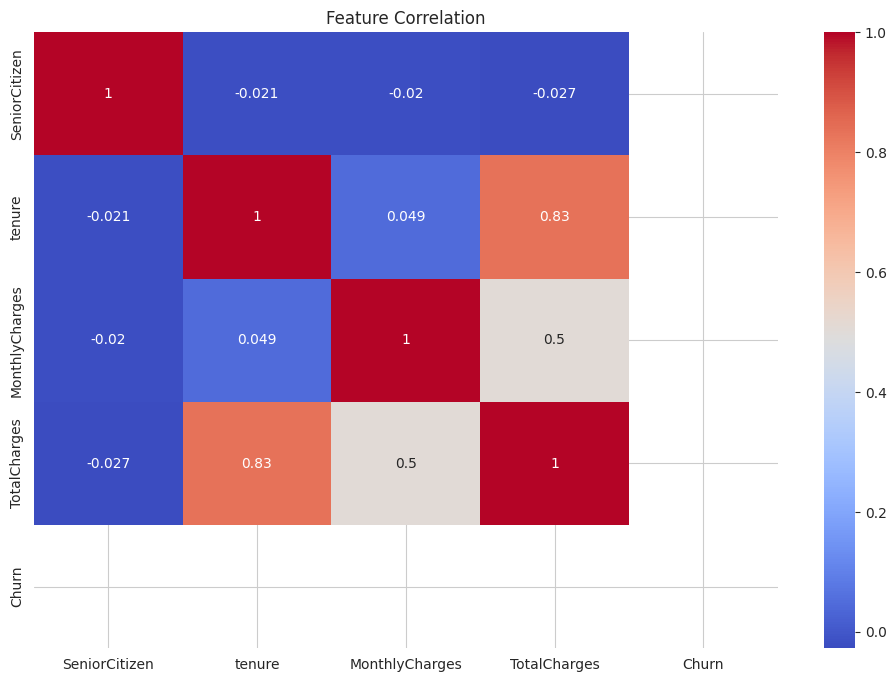

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")
plt.show()

In [13]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,


Insights from EDA:

1. Month-to-month contracts have the highest churn.
2. Customers with Fiber optic internet churn more.
3. High monthly charges increase churn risk.
4. Customers with short tenure are more likely to churn.
5. Electronic check payment users churn more.

In [15]:
plt.savefig("churn_contract.png")

<Figure size 640x480 with 0 Axes>